In [1]:
# Extension to the model: Leadership 
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from scipy import stats
import mesa

# Plotting settings
import matplotlib.ticker as mtick
from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}
sns.set_palette([
    "#8E44AD",  # violet/purple
    "#C08081",  # muted pinkish/brown
    "#f97743",  # bright orange
    "#2f6edd",  # royal blue
    "#28b36a",  # green
    "#333333",  # dark gray
    "#1ABC9C",  # teal
    "#E74C3C",  # red
])

# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel


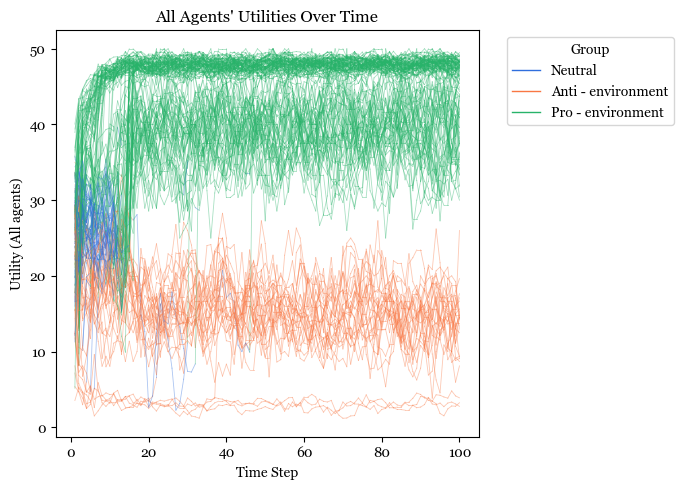

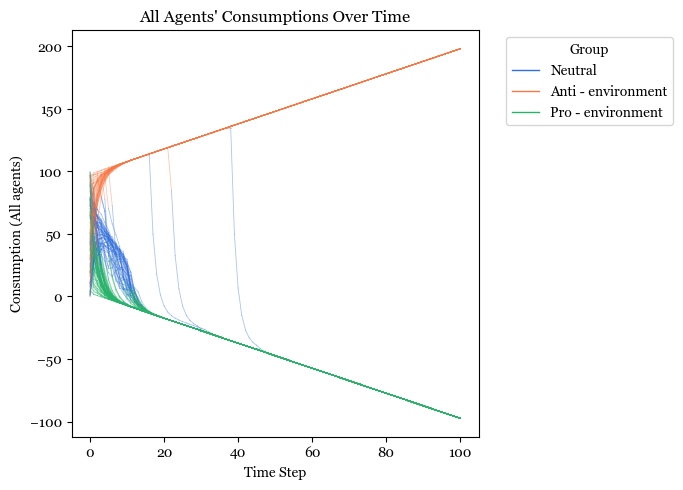

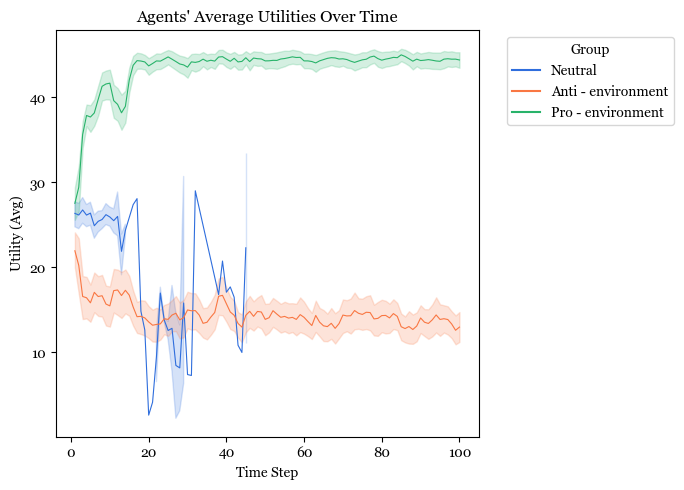

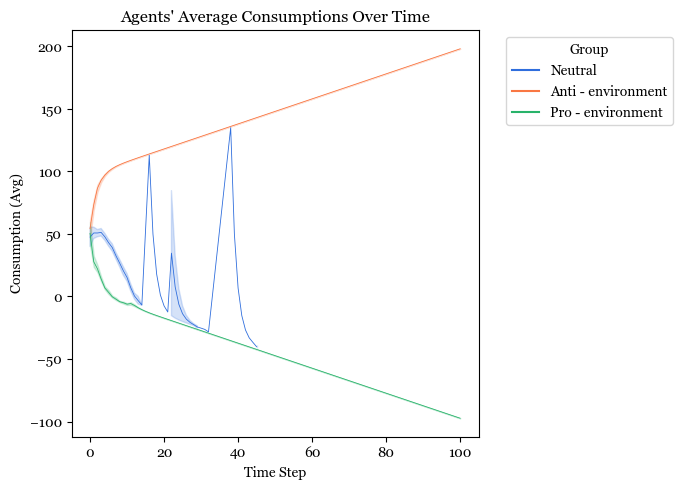

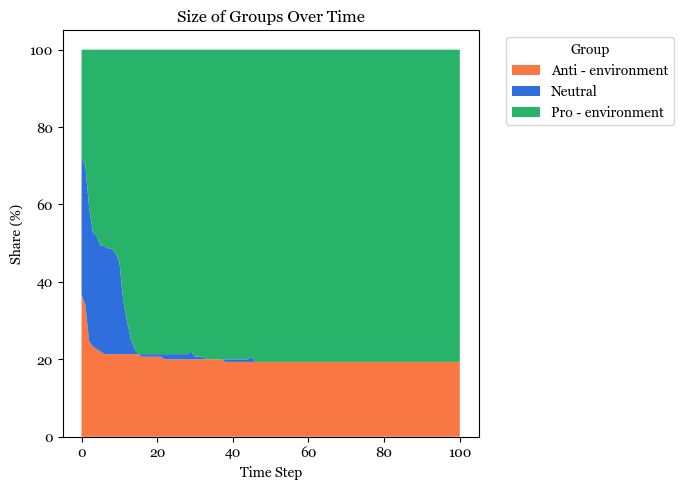

In [2]:
model_prop_neutral = statusgame_model(N=150, seed=666, lambda_s=1/2, memory=5,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=20, rho=3/4, seed_consumption=True, alpha=1/10, weights=[1/3, 1/3, 1/3], 
        fraction_leaders=0.02, fraction_attention=0.5, must_be_pro_fraction=1,beta=0.2)

for _ in range(100):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_agent_vars_dataframe().reset_index()

# Store node attributes
node_attrs = {}
for agent_id, agent in model_prop_neutral.agents_dict.items():
    node_attrs[agent_id] = {
         'group': agent.assigned_group,
         'is_leader': agent.is_leader,
         'pays_attention': agent.pays_attention
    }
# Assign these attributes to the graph nodes.
nx.set_node_attributes(model_prop_neutral.G, node_attrs)
nx.write_gexf(model_prop_neutral.G, "results/network_leaders.gexf")

plot_all_agent_graphs(model_prop_neutral_df, color_dict, output_folder="results/fig1_computational_noleaderstest", show_plots=True)

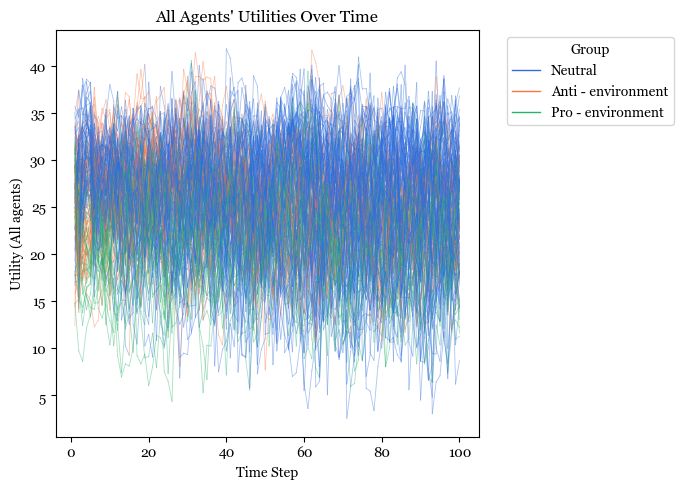

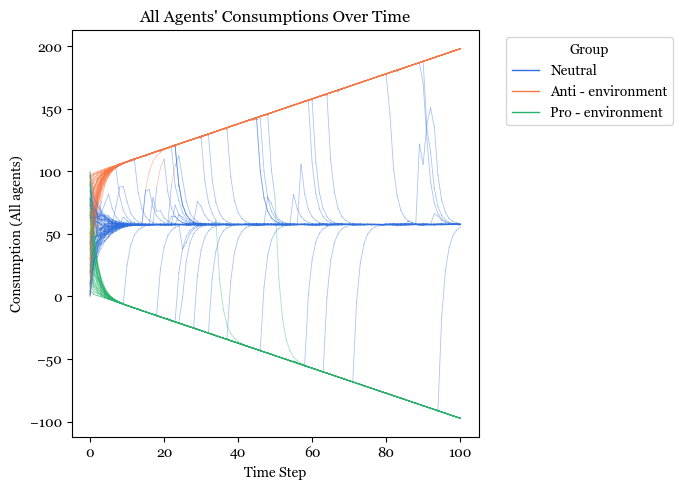

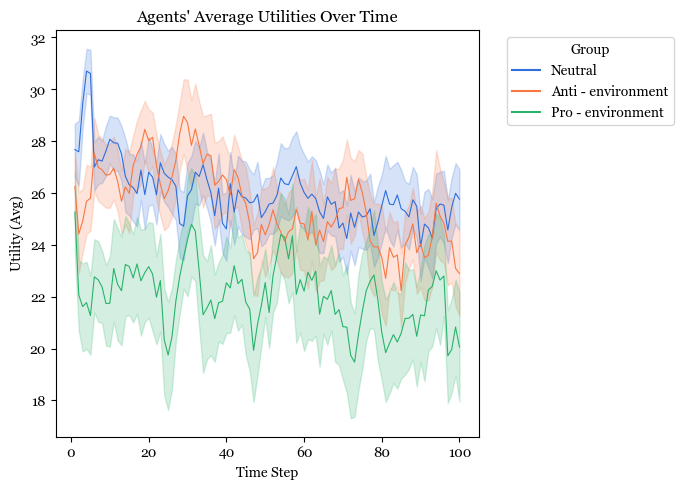

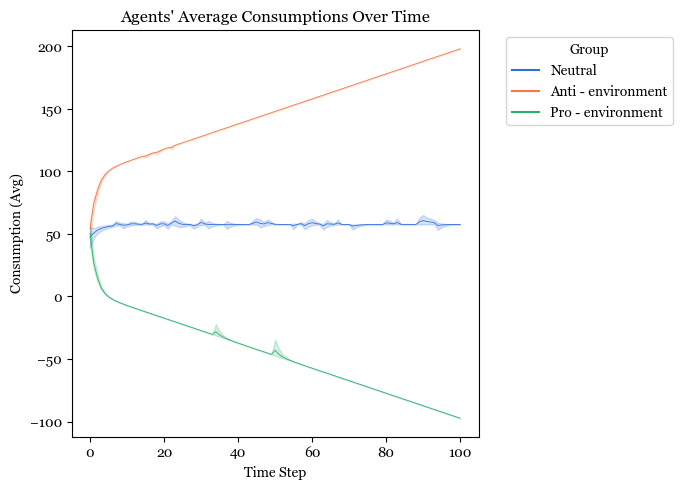

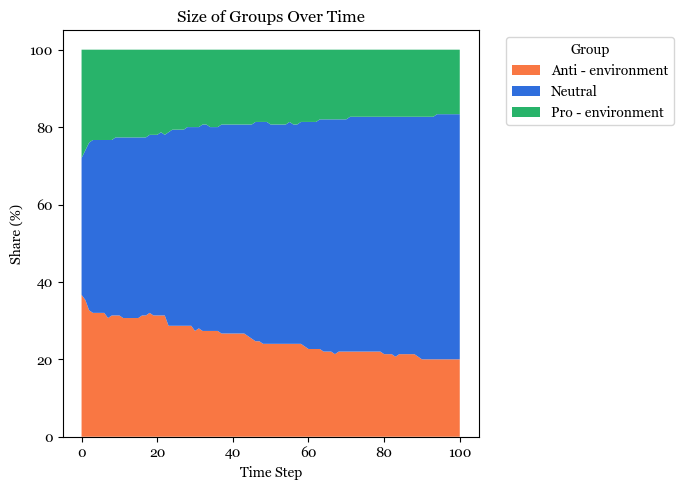

In [3]:
model_prop_neutral_noleaders = statusgame_model(N=150, seed=666, lambda_s=1/2, memory=5,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=20, rho=3/4, seed_consumption=True, alpha=1/10, weights=[1/3, 1/3, 1/3], 
        fraction_leaders=0, fraction_attention=0, beta=0)

for _ in range(100):
    model_prop_neutral_noleaders.step()
model_prop_neutral_noleaders_df = model_prop_neutral_noleaders.datacollector.get_agent_vars_dataframe().reset_index()

# Store node attributes
node_attrs = {}
for agent_id, agent in model_prop_neutral_noleaders.agents_dict.items():
    node_attrs[agent_id] = {
         'group': agent.assigned_group,
         'is_leader': agent.is_leader,
         'pays_attention': agent.pays_attention
    }
# Assign these attributes to the graph nodes.
nx.set_node_attributes(model_prop_neutral_noleaders.G, node_attrs)
nx.write_gexf(model_prop_neutral_noleaders.G, "results/network_noleaders.gexf")

plot_all_agent_graphs(model_prop_neutral_noleaders_df, color_dict, output_folder="results/fig1_computational_noleadertest", show_plots=True)

In [4]:
# Contour / 3d plots 
# Pro - environmentalism as a function of beta and fraction of attention
np.random.seed(666)
params = {"seed": 666, 
          "alpha": 1/10,
          'lambda_s': 1,
          'N':[150],
          "gamma": 1/2,
          "create_network": "watts_strogatz", 
          "k": [20], 
          "p": [1/100],
          "rho": 3/4,
          "seed_consumption": False, 
          "memory": 5, 
          "fraction_leaders": [0.02, 0.04, 0.08], 
          "fraction_attention": np.linspace(0,1,11), 
          "must_be_pro_fraction": 1,
          "beta": np.linspace(0,1,11), 
          }

results_batch_leadership = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=10, # To speed up
    max_steps=100,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
results_batch_leadership_df = pd.DataFrame(results_batch_leadership)
results_batch_leadership_df.to_csv("results_batch_leadership.csv")

  0%|          | 0/3630 [00:00<?, ?it/s]

In [ ]:
#Build plot 
#results_batch_leadership_df = pd.read_csv("results_batch_leadership.csv")

In [ ]:
# Build the plots using a scale from 
colors = ["#f7fbe9", "#28b36a"]  # white to the target color

# Create a custom colormap
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list("custom_green", colors)

In [6]:
# Refine datasets
grouped = (
    results_batch_leadership_df.groupby(["fraction_attention", "beta", "iteration"])["group"]
    .value_counts(normalize=True)   # gives fraction in each group
    .unstack(fill_value=0)          # create separate columns for each group
    .reset_index()
)
group_columns = ["Pro - environment", "Neutral", "Anti - environment"]

# Average across iterations
agg_df = (
    grouped
    .groupby(["beta", "fraction_attention"], as_index=False)["Pro - environment"]
    .mean()
)

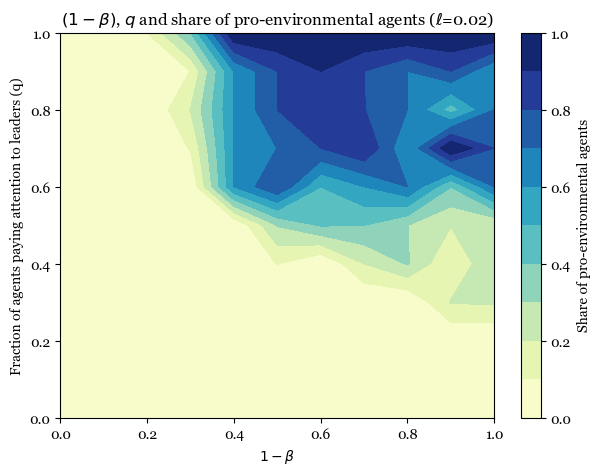

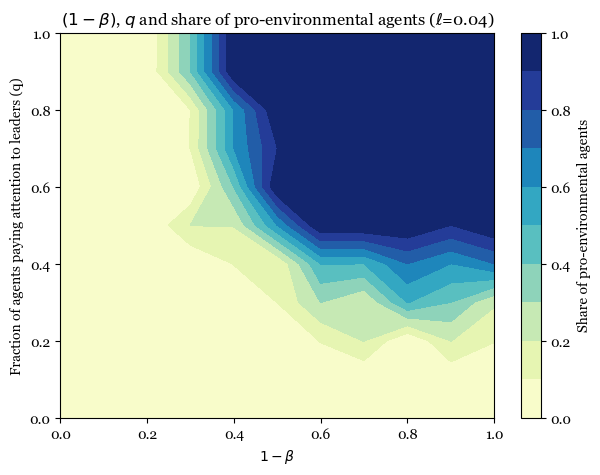

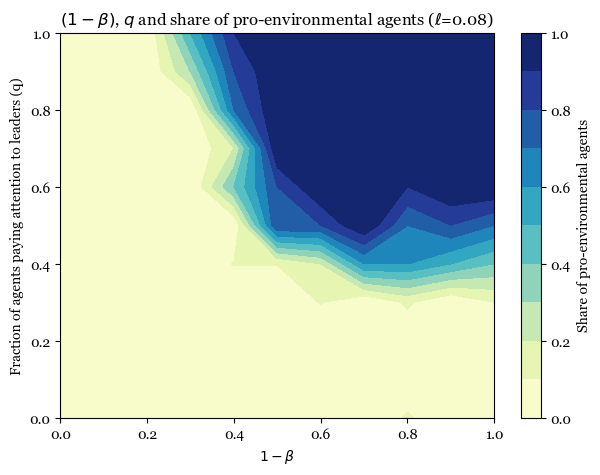

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for i in [0.02, 0.04, 0.08]:
    # Subset by fraction_leaders
    df = results_batch_leadership_df[
        results_batch_leadership_df["fraction_leaders"] == i
    ]
    # Get fraction of "Pro - environment" group by (q, beta, iteration)
    grouped = (
        df.groupby(["fraction_attention", "beta", "iteration"])["group"]
          .value_counts(normalize=True)   # fraction in each group
          .unstack(fill_value=0)          # separate columns for each group
          .reset_index()
    )
    
    # Average across iterations
    agg_df = (
        grouped.groupby(["fraction_attention", "beta"], as_index=False)["Pro - environment"]
               .mean()
    )
    
    # Create new column: 1 - beta
    agg_df["beta_flipped"] = 1 - agg_df["beta"]
    
    # Sort so meshgrid is built in ascending order
    beta_flip_vals = np.sort(agg_df["beta_flipped"].unique())
    fraction_attention_vals = np.sort(agg_df["fraction_attention"].unique())
    
    # Pivot so that rows=fraction_attention, columns=beta_flipped
    pivoted = agg_df.pivot(
        index="fraction_attention",
        columns="beta_flipped",
        values="Pro - environment"
    )
    # Ensure row/column order matches fraction_attention_vals, beta_flip_vals
    Z = pivoted.reindex(
        index=fraction_attention_vals, 
        columns=beta_flip_vals
    ).to_numpy()
    
    # Create the meshgrid: (x=beta_flipped, y=fraction_attention)
    B, Q = np.meshgrid(beta_flip_vals, fraction_attention_vals)

    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))
    levels = np.linspace(0, 1, 11)  # or however many you prefer
    cs = ax.contourf(
        B, Q, Z,
        levels=levels,
        cmap=custom_cmap
    )
    fig.colorbar(cs, ax=ax, label="Share of pro-environmental agents")

    # Label the new x-axis as (1 - beta) 
    ax.set_xlabel(r"$1 - \beta$")
    ax.set_ylabel("Fraction of agents paying attention to leaders (q)")
    ax.set_title(r"$(1-\beta)$, $q$ and share of pro-environmental agents ($\ell$={})".format(i))
    
    plt.savefig(f"results/contour_leadership_ell_{i}_flip.pdf", bbox_inches="tight", dpi=300)
    plt.show()
